
# 🌐 Clustering con K-Means en California Housing Data

## Objetivo de la notebook

En esta notebook vamos a aplicar **K-Means**, uno de los algoritmos más conocidos de **aprendizaje no supervisado**, para explorar cómo se forman grupos de observaciones similares.

La idea no es solamente ejecutar el algoritmo, sino comprender tres decisiones fundamentales:

- **qué variables usamos**;
- **cómo preparamos esas variables**;
- **qué valor de K elegimos**.

A lo largo del ejercicio veremos que los clusters no tienen un significado automático: el algoritmo encuentra grupos según las variables y distancias utilizadas, pero **la interpretación final corresponde al analista**.



## 1. Introducción teórica

El **clustering** es una técnica de **aprendizaje no supervisado** cuyo objetivo es agrupar observaciones de acuerdo con su similitud.

A diferencia de la clasificación supervisada, en clustering **no tenemos etiquetas** que indiquen a qué grupo pertenece cada caso.

### K-Means

K-Means busca dividir los datos en **K grupos** de manera que:

- los elementos de un mismo grupo sean lo más parecidos posible entre sí;
- los elementos de grupos diferentes sean lo más distintos posible.

El proceso básico es:

1. Elegir el número de clusters (**K**).
2. Inicializar K centroides.
3. Asignar cada observación al centroide más cercano.
4. Recalcular los centroides.
5. Repetir los pasos anteriores hasta que las asignaciones se estabilicen.

> **Idea clave:** K-Means trabaja con distancias. Por eso, la escala de las variables es muy importante.


## 2. Carga de librerías

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)



## 3. Contexto del dataset

Trabajaremos con el dataset **California Housing (1990)**.

Aunque no es un conjunto de datos actualizado, resulta útil para fines didácticos porque contiene información geográfica, demográfica y económica de distintas zonas de California.

Antes de seleccionar variables, vamos a observar **cuántas columnas tiene el dataset completo y cuáles están disponibles**.


In [2]:

# URL del dataset
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTYqV-5xcBvIIqYzq565M-YL7tevrh9oSSMRea2cZzko3zGSf6K9uGuQplLMzTPV7NSZLT_Qynmqn6g/pub?output=csv'

# Cargar el dataset completo
df_all = pd.read_csv(url)

print(f"Cantidad total de columnas disponibles: {df_all.shape[1]}")
print("\nColumnas disponibles:")
for i, col in enumerate(df_all.columns, start=1):
    print(f"{i}. {col}")


Cantidad total de columnas disponibles: 10

Columnas disponibles:
1. longitude
2. latitude
3. housing_median_age
4. total_rooms
5. total_bedrooms
6. population
7. households
8. median_income
9. median_house_value
10. ocean_proximity



### Variables que utilizaremos inicialmente

Para comenzar trabajaremos con:

- `longitude` → longitud geográfica.
- `latitude` → latitud geográfica.
- `median_house_value` → valor medio de las viviendas.

En el **primer modelo**, K-Means utilizará solamente `longitude` y `latitude`.

La variable `median_house_value` quedará inicialmente **fuera del modelo** y la usaremos después para interpretar si los clusters geográficos presentan diferencias de precio.


In [3]:
# Seleccionar las variables que utilizaremos en el ejemplo
dfhouse = df_all[['longitude', 'latitude', 'median_house_value']].copy()

display(dfhouse.head())


,longitude,latitude,median_house_value
0,-122.23,37.88,452600
1,-122.22,37.86,358500
2,-122.24,37.85,352100
3,-122.25,37.85,341300
4,-122.25,37.85,342200


In [4]:
# Información general
dfhouse.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   median_house_value  20640 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 483.9 KB


In [5]:
# Estadísticos descriptivos
display(dfhouse.describe())


,longitude,latitude,median_house_value
count,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,206855.816909
std,2.003532,2.135952,115395.615874
min,-124.350000,32.540000,14999.000000
25%,-121.800000,33.930000,119600.000000
50%,-118.490000,34.260000,179700.000000
75%,-118.010000,37.710000,264725.000000
max,-114.310000,41.950000,500001.000000



## 4. Análisis exploratorio de datos

Antes de aplicar clustering conviene explorar las variables:

- observar sus distribuciones;
- detectar diferencias de escala;
- identificar valores extremos;
- analizar relaciones entre variables.

Esto es especialmente importante en K-Means porque el algoritmo utiliza **distancias euclidianas**.


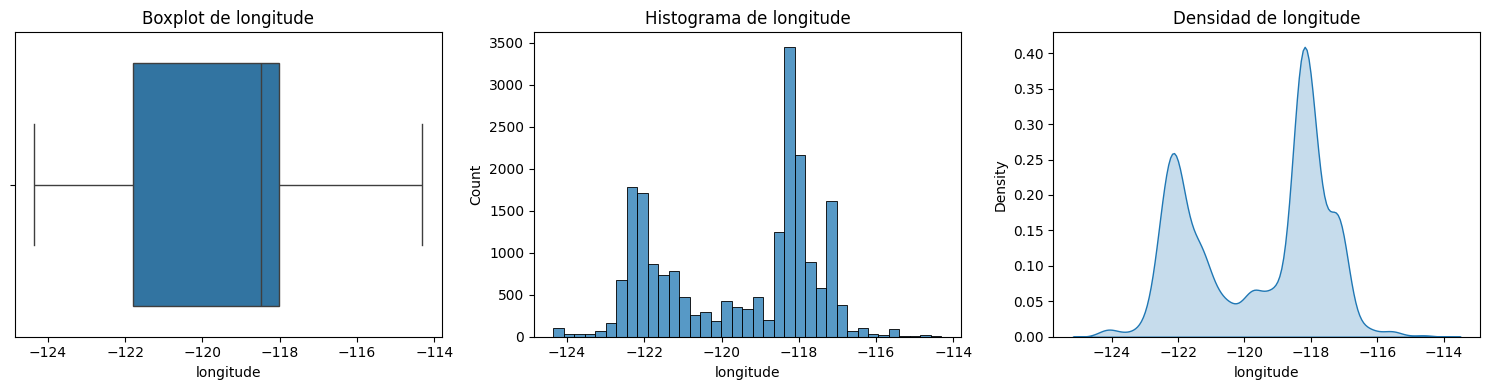

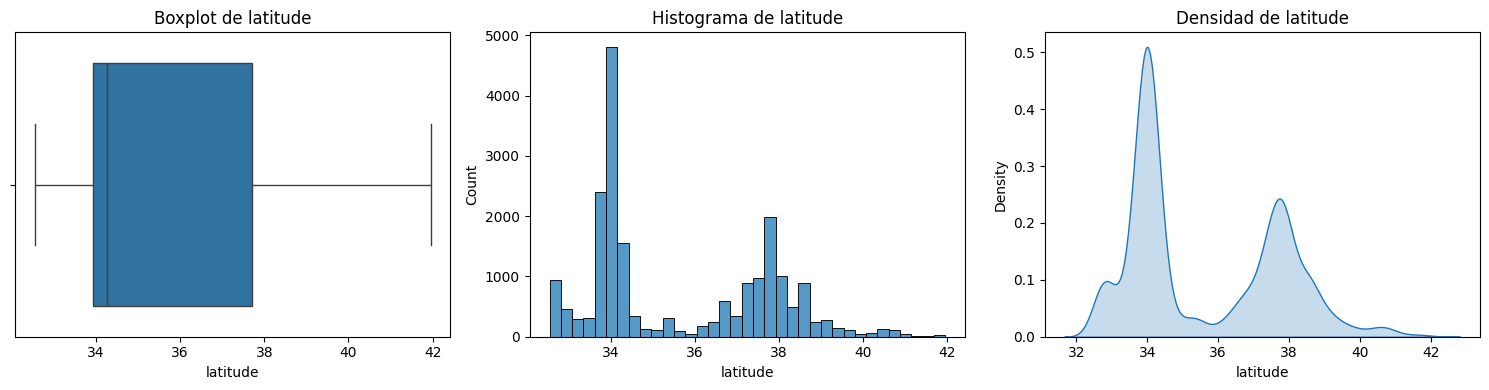

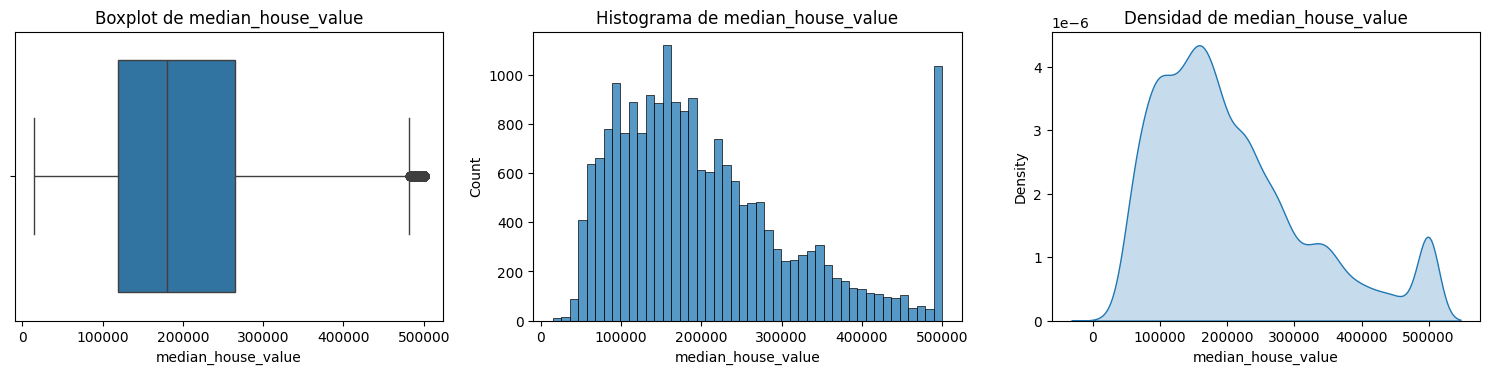

In [6]:

# Distribuciones univariadas
vars_to_plot = ['longitude', 'latitude', 'median_house_value']

for var in vars_to_plot:
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    sns.boxplot(x=dfhouse[var], ax=ax[0])
    ax[0].set_title(f"Boxplot de {var}")

    sns.histplot(dfhouse[var], kde=False, ax=ax[1])
    ax[1].set_title(f"Histograma de {var}")

    sns.kdeplot(dfhouse[var], fill=True, ax=ax[2])
    ax[2].set_title(f"Densidad de {var}")

    plt.tight_layout()
    plt.show()



### Lectura del análisis exploratorio

- `longitude` y `latitude` describen la distribución espacial de las observaciones.
- `median_house_value` presenta una distribución asimétrica y valores extremos.
- Las variables están expresadas en escalas muy diferentes.

Esto anticipa una decisión importante: **antes de aplicar K-Means debemos estandarizar las variables utilizadas por el algoritmo**.


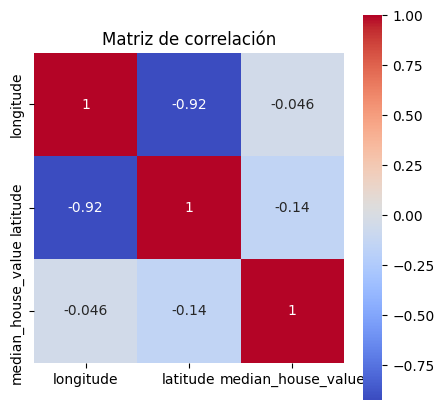

In [7]:
# Correlación entre variables
plt.figure(figsize=(5, 5))
sns.heatmap(dfhouse.corr(numeric_only=True), annot=True, cmap='coolwarm', square=True)
plt.title("Matriz de correlación")
plt.show()



La correlación permite observar asociaciones lineales entre las variables.

Una correlación baja no significa automáticamente que una variable sea "mejor" para clustering. Lo importante es comprender que distintas variables pueden aportar **dimensiones diferentes del problema**.


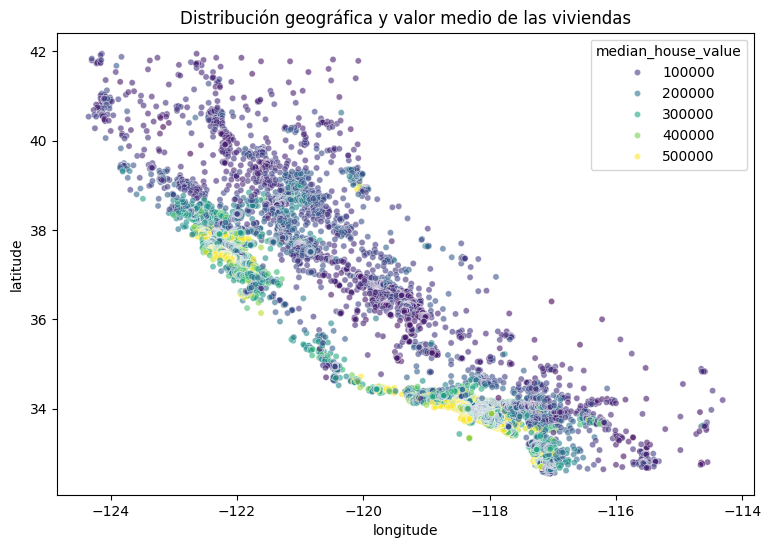

In [8]:
# Distribución geográfica
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=dfhouse,
    x='longitude',
    y='latitude',
    hue='median_house_value',
    palette='viridis',
    s=20,
    alpha=0.6
)
plt.title("Distribución geográfica y valor medio de las viviendas")
plt.show()



## 5. Preparación de los datos

### ¿Por qué estandarizar?

K-Means asigna observaciones a partir de distancias.

Si una variable tiene una escala mucho mayor que otra, puede influir desproporcionadamente en esas distancias.

Utilizaremos **StandardScaler**, que transforma cada variable para que tenga aproximadamente:

- media = 0;
- desvío estándar = 1.

> Esto no cambia la estructura relativa de cada variable, pero permite compararlas en una escala común.


In [9]:

# Primer conjunto de variables: solamente ubicación
X_geo = dfhouse[['longitude', 'latitude']].copy()

scaler_geo = StandardScaler()
X_geo_scaled = scaler_geo.fit_transform(X_geo)

print("Forma del conjunto utilizado para clustering:", X_geo_scaled.shape)


Forma del conjunto utilizado para clustering: (20640, 2)



## 6. Primera aplicación de K-Means

Comenzaremos con **K = 3** como ejemplo inicial.

En esta etapa el algoritmo utiliza solamente:

- longitud;
- latitud.

Por lo tanto, los clusters estarán determinados exclusivamente por **proximidad geográfica**.


In [10]:

# K-Means con K=3
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_3 = kmeans_3.fit_predict(X_geo_scaled)


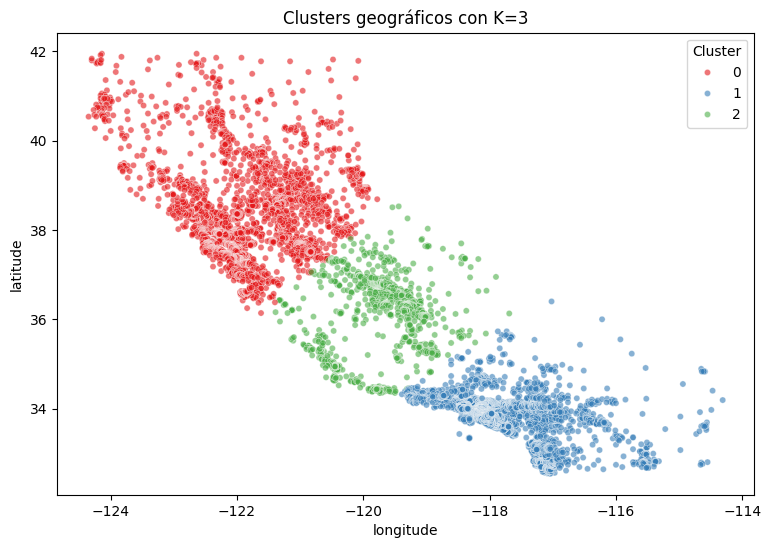

In [11]:

# Visualización geográfica de los clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=X_geo,
    x='longitude',
    y='latitude',
    hue=labels_3,
    palette='Set1',
    s=20,
    alpha=0.6
)
plt.title("Clusters geográficos con K=3")
plt.legend(title="Cluster")
plt.show()



### El algoritmo encuentra grupos, pero no los interpreta

K-Means puede identificar grupos de observaciones similares, pero **no les asigna nombres ni significado real**.

Por eso, después de obtener los clusters, debemos caracterizarlos.


In [12]:

# Incorporar los clusters al dataframe para analizarlos
df_geo = dfhouse.copy()
df_geo['cluster_geo'] = labels_3

# Resumen de los clusters
resumen_geo = (
    df_geo
    .groupby('cluster_geo')
    .agg(
        cantidad=('cluster_geo', 'size'),
        longitud_media=('longitude', 'mean'),
        latitud_media=('latitude', 'mean'),
        precio_mediano=('median_house_value', 'median')
    )
    .round(2)
)

display(resumen_geo)


,cantidad,longitud_media,latitud_media,precio_mediano
cluster_geo,,,,
0,7761,-121.93,38.11,180300.0
1,11033,-117.88,33.82,189600.0
2,1846,-119.71,36.00,88600.0


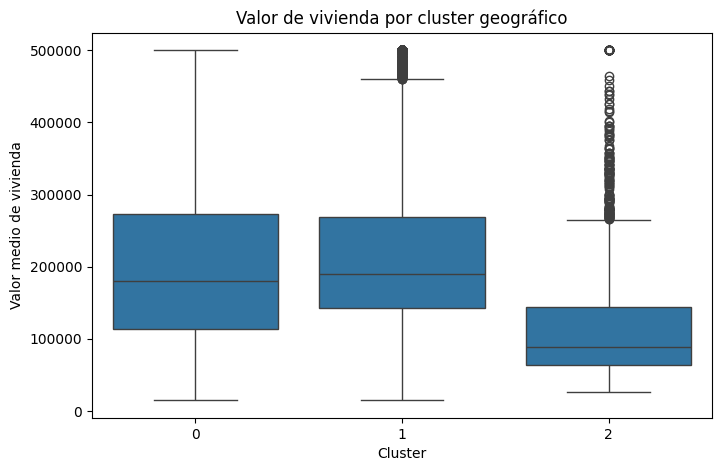

In [13]:

# Comparar los precios de vivienda entre clusters
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_geo,
    x='cluster_geo',
    y='median_house_value'
)
plt.title("Valor de vivienda por cluster geográfico")
plt.xlabel("Cluster")
plt.ylabel("Valor medio de vivienda")
plt.show()



En este punto es importante distinguir dos cosas:

- **El precio no fue utilizado para construir los clusters.**
- Sin embargo, podemos utilizarlo después para **caracterizar e interpretar** los grupos obtenidos.

Si aparecen diferencias de precio entre clusters, esas diferencias son un resultado posterior de la segmentación geográfica, no una variable que haya guiado al algoritmo.



## 7. ¿Cómo elegir el número de clusters?

Elegir **K** es una de las decisiones centrales de K-Means.

Vamos a utilizar dos criterios complementarios:

### Método del codo

Analiza la **inercia**: la suma de las distancias cuadráticas de las observaciones respecto del centroide de su cluster.

A medida que aumenta K, la inercia siempre disminuye. Buscamos un punto a partir del cual agregar nuevos clusters produce mejoras cada vez menores.

### Coeficiente de Silhouette

Evalúa simultáneamente:

- qué tan cerca está cada observación de su propio cluster;
- qué tan separada está de los demás clusters.

Su valor puede ir aproximadamente de **-1 a 1**:

- cercano a 1 → grupos bien definidos;
- cercano a 0 → grupos poco separados;
- negativo → posibles asignaciones problemáticas.

> Ninguna métrica reemplaza la interpretación. Un K matemáticamente conveniente no siempre es el más útil para el problema real.


In [14]:

# Evaluar distintos valores de K
valores_k = range(2, 9)

modelos_geo = {}
resultados_geo = []

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = modelo.fit_predict(X_geo_scaled)

    # Para agilizar el cálculo, Silhouette se estima sobre una muestra
    sil = silhouette_score(
        X_geo_scaled,
        etiquetas,
        sample_size=min(5000, len(X_geo_scaled)),
        random_state=42
    )

    modelos_geo[k] = modelo

    resultados_geo.append({
        'K': k,
        'inercia': modelo.inertia_,
        'silhouette': sil
    })

resultados_geo = pd.DataFrame(resultados_geo)

display(resultados_geo.round(3))


,K,inercia,silhouette
0,2,6240.810,0.755
1,3,4254.552,0.647
2,4,3301.756,0.610
3,5,2435.588,0.590
4,6,1869.255,0.577
5,7,1599.057,0.578
6,8,1416.422,0.494


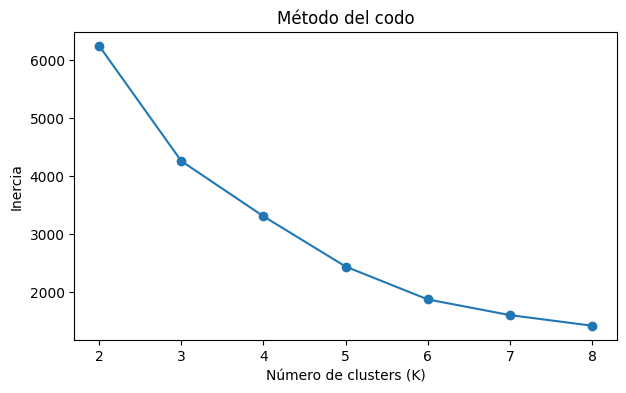

In [15]:

# Método del codo
plt.figure(figsize=(7, 4))
plt.plot(
    resultados_geo['K'],
    resultados_geo['inercia'],
    marker='o'
)
plt.title("Método del codo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.show()


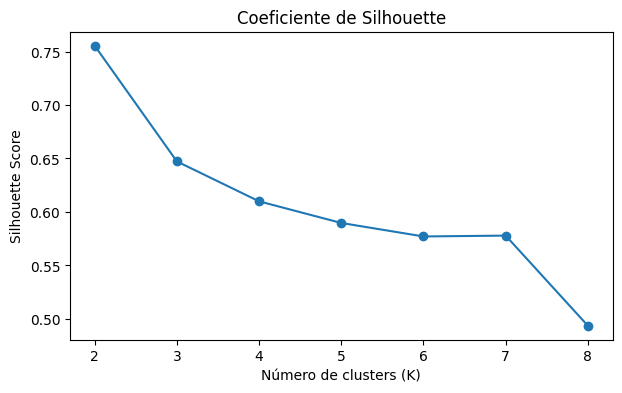

In [16]:

# Coeficiente de Silhouette
plt.figure(figsize=(7, 4))
plt.plot(
    resultados_geo['K'],
    resultados_geo['silhouette'],
    marker='o'
)
plt.title("Coeficiente de Silhouette")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()


In [17]:

# Mostrar el K con mayor Silhouette
mejor_fila_geo = resultados_geo.loc[resultados_geo['silhouette'].idxmax()]

print(
    f"Mayor Silhouette: K={int(mejor_fila_geo['K'])} "
    f"con score={mejor_fila_geo['silhouette']:.3f}"
)


Mayor Silhouette: K=2 con score=0.755



### ¿Cómo interpretar estos resultados?

No debemos elegir K solamente porque tenga el mayor Silhouette.

Conviene considerar conjuntamente:

1. la forma del gráfico del codo;
2. el valor de Silhouette;
3. la visualización de los grupos;
4. la facilidad para interpretar cada cluster;
5. la utilidad de la segmentación para el problema analizado.

Por eso vamos a comparar visualmente algunos valores de K.


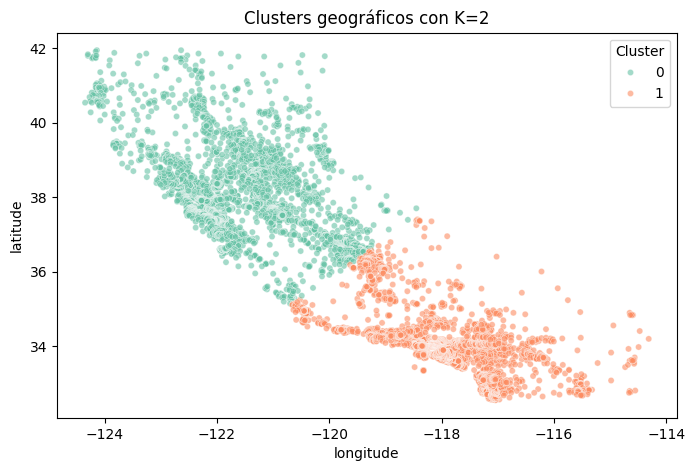

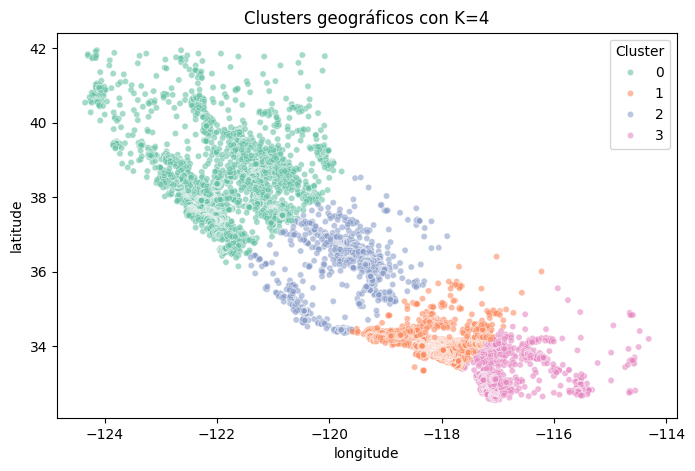

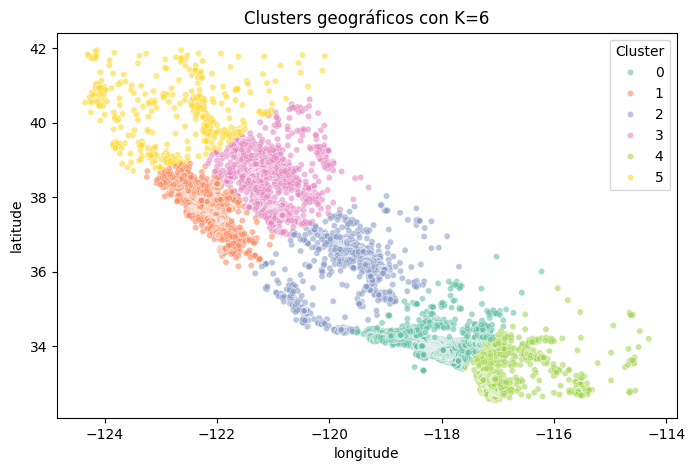

In [18]:

# Comparación visual de algunos valores de K
for k in [2, 4, 6]:
    labels = modelos_geo[k].labels_

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=X_geo,
        x='longitude',
        y='latitude',
        hue=labels,
        palette='Set2',
        s=20,
        alpha=0.6
    )

    plt.title(f"Clusters geográficos con K={k}")
    plt.legend(title="Cluster")
    plt.show()



### Reflexión

Aumentar K produce una segmentación cada vez más detallada, pero **más clusters no significa automáticamente mejores clusters**.

Con valores pequeños de K obtenemos divisiones generales.

Con valores mayores, el algoritmo crea segmentos más específicos, aunque pueden ser menos compactos, más difíciles de interpretar o poco útiles para el objetivo del análisis.



## 8. ¿Qué ocurre si agregamos una nueva variable?

Hasta ahora K-Means utilizó únicamente la ubicación.

Ahora vamos a incorporar:

- `longitude`;
- `latitude`;
- `median_house_value`.

Esto cambia la definición de **similitud**.

Dos observaciones ya no serán consideradas similares solamente porque estén cerca geográficamente: también deberá considerarse el valor de las viviendas.

> Como todas las variables se estandarizan previamente, ninguna debería dominar el cálculo únicamente por estar expresada en una escala numérica mayor.


In [19]:

# Segundo conjunto de variables: ubicación + precio
X_geo_precio = dfhouse[
    ['longitude', 'latitude', 'median_house_value']
].copy()

scaler_geo_precio = StandardScaler()
X_geo_precio_scaled = scaler_geo_precio.fit_transform(X_geo_precio)

print("Forma del segundo conjunto:", X_geo_precio_scaled.shape)


Forma del segundo conjunto: (20640, 3)


In [20]:

# Evaluar nuevamente distintos valores de K
modelos_geo_precio = {}
resultados_geo_precio = []

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = modelo.fit_predict(X_geo_precio_scaled)

    sil = silhouette_score(
        X_geo_precio_scaled,
        etiquetas,
        sample_size=min(5000, len(X_geo_precio_scaled)),
        random_state=42
    )

    modelos_geo_precio[k] = modelo

    resultados_geo_precio.append({
        'K': k,
        'inercia': modelo.inertia_,
        'silhouette': sil
    })

resultados_geo_precio = pd.DataFrame(resultados_geo_precio)

display(resultados_geo_precio.round(3))


,K,inercia,silhouette
0,2,26768.422,0.545
1,3,18289.041,0.529
2,4,12109.449,0.490
3,5,9863.616,0.472
4,6,8115.642,0.412
5,7,6564.137,0.409
6,8,5796.354,0.395


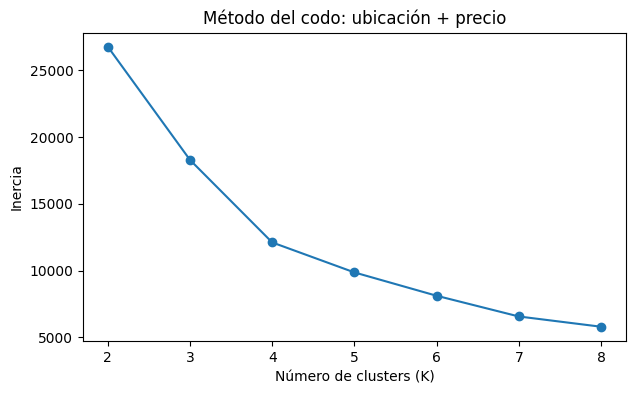

In [21]:

# Método del codo para ubicación + precio
plt.figure(figsize=(7, 4))
plt.plot(
    resultados_geo_precio['K'],
    resultados_geo_precio['inercia'],
    marker='o'
)
plt.title("Método del codo: ubicación + precio")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.show()


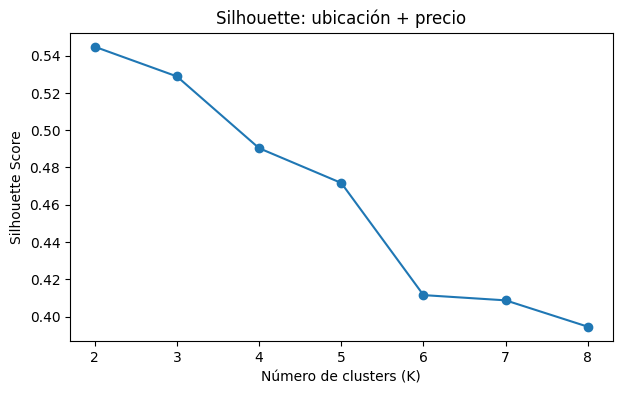

In [22]:

# Silhouette para ubicación + precio
plt.figure(figsize=(7, 4))
plt.plot(
    resultados_geo_precio['K'],
    resultados_geo_precio['silhouette'],
    marker='o'
)
plt.title("Silhouette: ubicación + precio")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()


In [23]:

# Comparación de Silhouette entre ambos modelos
comparacion = resultados_geo[
    ['K', 'silhouette']
].merge(
    resultados_geo_precio[['K', 'silhouette']],
    on='K',
    suffixes=('_solo_ubicacion', '_ubicacion_precio')
)

display(comparacion.round(3))


,K,silhouette_solo_ubicacion,silhouette_ubicacion_precio
0,2,0.755,0.545
1,3,0.647,0.529
2,4,0.610,0.490
3,5,0.590,0.472
4,6,0.577,0.412
5,7,0.578,0.409
6,8,0.494,0.395



### ¿Qué debemos observar?

La incorporación de `median_house_value` modifica el espacio en el que K-Means calcula las distancias.

Por eso debemos analizar:

- si cambia el K que parece más razonable;
- si mejora o empeora el Silhouette;
- si los grupos conservan una estructura espacial clara;
- si aparecen diferencias económicas más marcadas;
- si la nueva segmentación resulta más o menos interpretable.

La comparación permite mostrar una idea central del clustering:

> **Cambiar las variables cambia la noción de similitud y, por lo tanto, puede cambiar completamente los clusters.**


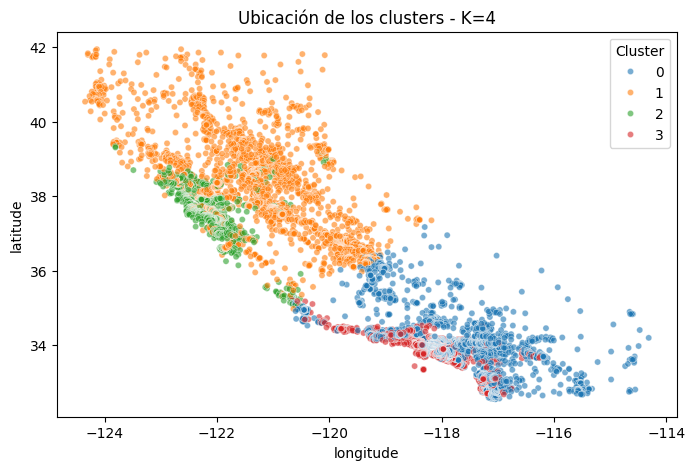

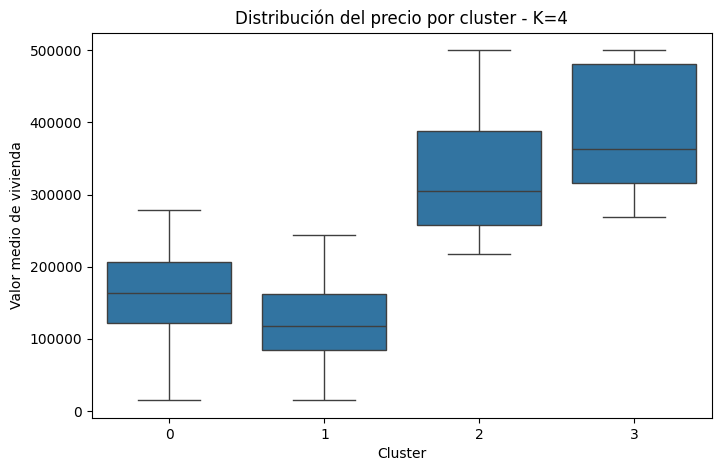

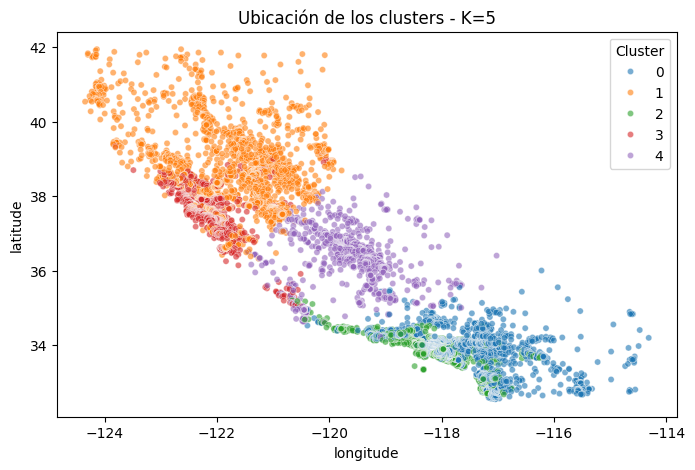

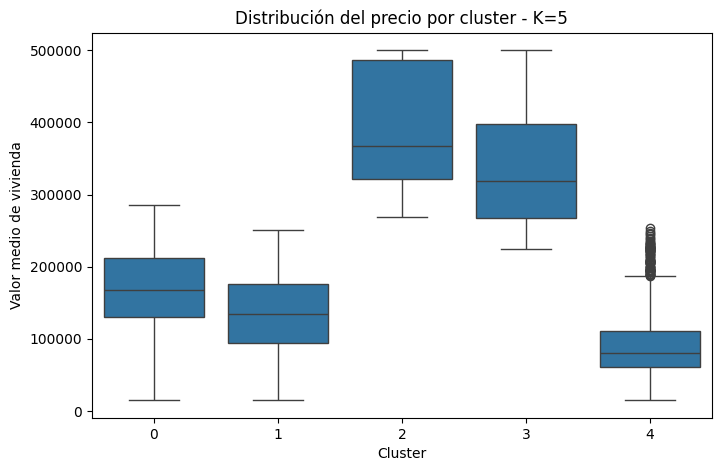

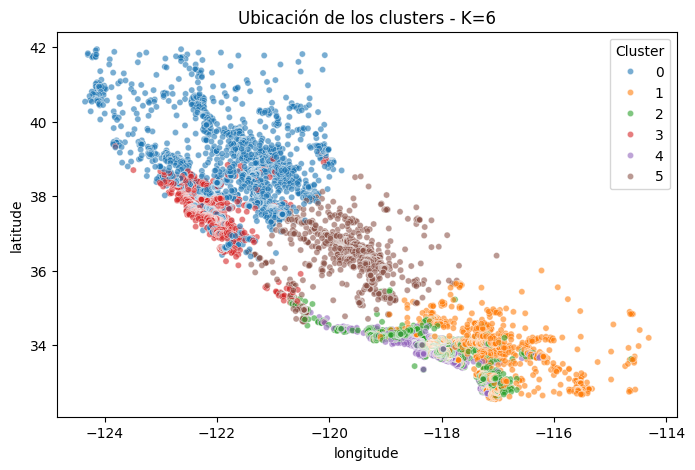

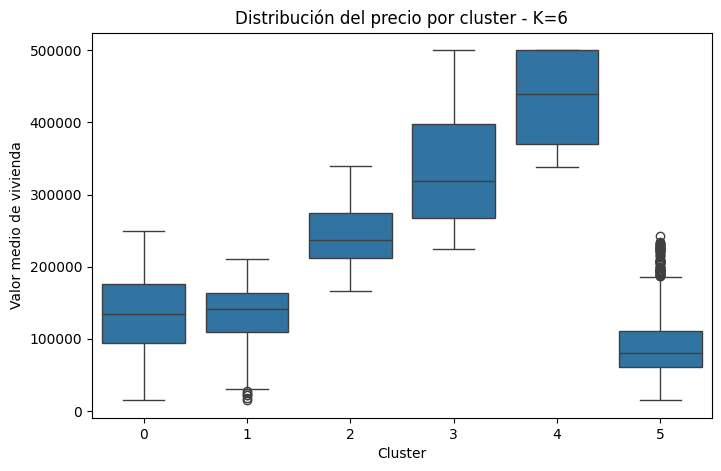

In [24]:

# Visualización para K=4, K=5 y K=6
for k in [4, 5, 6]:
    labels = modelos_geo_precio[k].labels_

    df_temp = dfhouse.copy()
    df_temp['cluster'] = labels

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df_temp,
        x='longitude',
        y='latitude',
        hue='cluster',
        palette='tab10',
        s=20,
        alpha=0.6
    )
    plt.title(f"Ubicación de los clusters - K={k}")
    plt.legend(title="Cluster")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_temp,
        x='cluster',
        y='median_house_value'
    )
    plt.title(f"Distribución del precio por cluster - K={k}")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio de vivienda")
    plt.show()



## 9. Caracterización de un modelo elegido

Para interpretar un clustering no alcanza con mirar colores en un gráfico.

Como ejemplo, vamos a caracterizar un modelo con **K = 4**. Esto no implica afirmar que K=4 sea necesariamente el valor óptimo: lo utilizamos para mostrar cómo analizar los grupos obtenidos.


In [25]:

# Caracterización de los clusters para K=4
k_ejemplo = 4

df_interpretacion = dfhouse.copy()
df_interpretacion['cluster'] = modelos_geo_precio[k_ejemplo].labels_

resumen_clusters = (
    df_interpretacion
    .groupby('cluster')
    .agg(
        cantidad=('cluster', 'size'),
        longitud_media=('longitude', 'mean'),
        latitud_media=('latitude', 'mean'),
        precio_medio=('median_house_value', 'mean'),
        precio_mediano=('median_house_value', 'median')
    )
    .round(2)
)

display(resumen_clusters)


,cantidad,longitud_media,latitud_media,precio_medio,precio_mediano
cluster,,,,,
0,9047,-117.92,33.92,163618.16,163000.0
1,5803,-121.44,38.12,124220.95,118100.0
2,3031,-122.14,37.57,331047.92,305600.0
3,2759,-118.22,33.90,386005.84,363600.0



A partir de esta tabla podemos comenzar a describir los clusters.

Por ejemplo:

- ¿qué grupos presentan precios más altos o más bajos?;
- ¿qué ubicación media tiene cada grupo?;
- ¿qué cluster concentra más observaciones?;
- ¿los grupos parecen representar regiones geográficas, segmentos económicos o una combinación?

El algoritmo **no responde estas preguntas por sí solo**. La interpretación corresponde al analista.



## 10. Conclusiones

Este ejercicio permite observar varias ideas centrales sobre K-Means:

### 1. La escala importa

Como K-Means utiliza distancias, las variables deben encontrarse en escalas comparables. Por eso utilizamos **StandardScaler**.

### 2. K debe analizarse, no elegirse al azar

El método del codo y el coeficiente de Silhouette ayudan a evaluar distintas alternativas, pero no reemplazan el criterio analítico.

### 3. Las variables definen qué significa "parecido"

Cuando utilizamos solamente ubicación, los clusters reflejan principalmente proximidad geográfica.

Cuando agregamos precio, modificamos la definición de similitud y aparecen agrupamientos diferentes.

### 4. El algoritmo no interpreta los clusters

K-Means devuelve etiquetas como 0, 1, 2 o 3. El significado de esos grupos debe construirse analizando sus características.

### 5. El mejor clustering no es necesariamente el que obtiene el mayor puntaje

La calidad matemática es importante, pero también debemos considerar:

- interpretabilidad;
- coherencia;
- utilidad práctica;
- relación con el problema que queremos estudiar.

> **Mensaje clave:** en clustering, seleccionar variables e interpretar los resultados es tan importante como ejecutar el algoritmo.



## 11. Tarea

Modificar esta notebook aplicando **K-Means con nuevas variables disponibles en el dataset**.

Antes de comenzar, revisen nuevamente la lista completa de columnas mostrada al inicio.

### Consigna

1. Seleccionar al menos **dos variables adicionales**.
2. Justificar brevemente por qué podrían ser útiles para formar grupos.
3. Estandarizar las variables.
4. Probar diferentes valores de K.
5. Analizar:
   - método del codo;
   - coeficiente de Silhouette;
   - visualización de los clusters;
   - características de cada grupo.
6. Comparar los resultados con el modelo original.

### Preguntas para orientar el análisis

- ¿Cómo cambia la calidad estadística de los clusters?
- ¿Cómo cambia su interpretación?
- ¿Los nuevos clusters parecen organizarse por ubicación, precio, características sociales o una combinación?
- ¿Agregar variables produjo grupos más útiles o simplemente más complejos?
- ¿Qué K elegirían y por qué?
- ¿Cómo describirían cada cluster en términos del problema real?

### Entrega

Presentar:

- la notebook modificada;
- una breve explicación de las decisiones tomadas;
- una interpretación de los clusters obtenidos.

> El objetivo no es encontrar una única respuesta correcta, sino **comprender cómo las decisiones analíticas modifican los resultados del clustering**.
